# Week 4 Day 3: Confusion Matrix Breakdown

Generate a confusion matrix heatmap and extract TP, TN, FP, and FN counts.

True Negatives  (TN): 25
False Positives (FP): 2
False Negatives (FN): 2
True Positives  (TP): 21


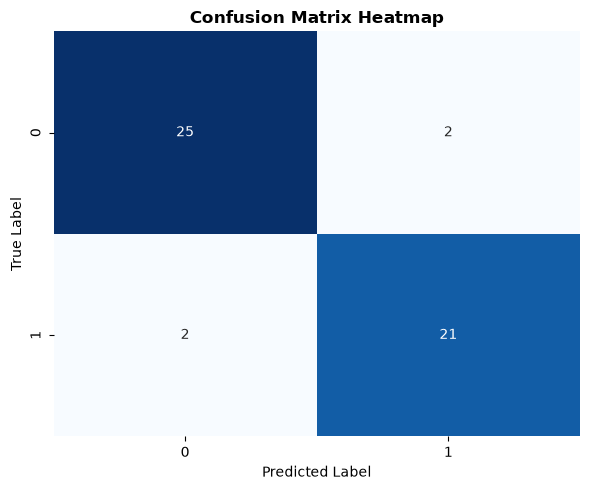

In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

output_dir = "saved_charts"
os.makedirs(output_dir, exist_ok=True)

X, y = make_classification(
    n_samples=200, n_features=4, random_state=42
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model = LogisticRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives  (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives  (TP): {tp}")

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix Heatmap", fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig(
    os.path.join(output_dir, "Day3_ConfusionMatrix.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()